# Insider Trading Alpha: walkthrough

This notebook walks through the results produced by the pipeline. It only **reads** `results/`, so it runs in seconds.
To recompute everything from raw data:

```bash
python scripts/download_data.py --email you@example.com
python scripts/run_pipeline.py
```

**Research question:** do corporate insiders' open-market purchases (SEC Form 4, code `P`) predict abnormal returns? Can an outsider, trading only after the filing is public, still profit after costs?

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image

RES = Path("../results")
FIG = RES / "figures"
pd.set_option("display.width", 200)
meta = json.loads((RES / "run_meta.json").read_text())
{k: meta[k] for k in ["first_filing", "last_filing", "n_raw_lines", "n_purchase_events", "n_sale_events",
                      "n_tickers_priced", "oos_start", "best_model"]}

{'first_filing': '2010-01-04', 'last_filing': '2026-03-31', 'n_raw_lines': 1970299, 'n_purchase_events': 108751, 'n_sale_events': 370719, 'n_tickers_priced': 5420, 'oos_start': '2016-01-05', 'best_model': 'gbm'}

## 1. Data coverage

Purchase events at each stage of the pipeline, by filing year:

- **has_price_data:** a Yahoo ticker was found, using either the symbol on the filing or the company's current ticker.
- **price_validated:** the market close on the trade date is within 30% of the price the insider reported.
- **tradeable_entry:** the stock traded on the session after the filing.

The gap between the first and last columns is mostly delisted companies. This is the main limitation of free data.

In [2]:
pd.read_csv(RES / "data_coverage.csv", index_col=0)

,purchase_events,has_ticker_candidate,has_price_data,price_validated,tradeable_entry
filing_date,,,,,
2010,16365,16042,5670,5426,5426
2011,17961,17625,7398,7069,7069
2012,15334,15047,6921,6521,6521
2013,12842,12542,5777,5382,5382
2014,14688,14499,6925,6614,6614
2015,16662,16442,8226,7904,7904
2016,14239,14041,7714,7408,7408
2017,12264,11976,6981,6616,6616
2018,14382,14084,8874,8435,8435


## 2. Event study

Buy-and-hold abnormal return (BHAR) vs IWM, measured from the **open of the session after the filing date**. Form 4s can be filed until 10pm, so trading on the filing date itself would be look-ahead. Returns are winsorised at 1%/99%; t-statistics are clustered by filing month.

In [3]:
es = pd.read_csv(RES / "event_study.csv")
cols = ["group", "n_events", "bhar_5d", "t_5d", "bhar_21d", "t_21d", "bhar_63d", "t_63d", "bhar_126d", "t_126d"]
es[cols].round(4)

,group,n_events,bhar_5d,t_5d,bhar_21d,t_21d,bhar_63d,t_63d,bhar_126d,t_126d
0,All purchases,108751,0.0058,11.9241,0.0047,3.0967,0.0024,0.8180,-0.0012,-0.3040
1,Purchases - investable,78327,0.0045,8.4101,0.0033,1.9632,-0.0001,-0.0409,-0.0069,-1.7166
2,CEO/CFO,26542,0.0073,9.1840,0.0061,3.0604,0.0028,0.6311,0.0008,0.1196
3,Other officer,16563,0.0050,5.4371,0.0027,1.2909,-0.0015,-0.3314,-0.0053,-1.0089
4,Director,51351,0.0049,9.8453,0.0045,2.8002,0.0054,2.0249,0.0063,1.6200
5,10% owner,11448,0.0070,5.6410,0.0019,0.6151,-0.0072,-1.0339,-0.0243,-2.7619
6,"Cluster buy (>=2 insiders, 30d)",64799,0.0062,10.2027,0.0050,2.9295,0.0032,0.8443,-0.0024,-0.5474
7,Single-insider buy,43952,0.0052,9.3653,0.0041,2.5386,0.0013,0.4632,0.0006,0.1309
8,Opportunistic trader,22345,0.0053,8.1640,0.0059,3.6706,0.0088,2.5749,0.0118,2.6374
9,Routine trader,6888,0.0022,2.2610,0.0019,0.7053,0.0077,1.2733,0.0074,0.7825


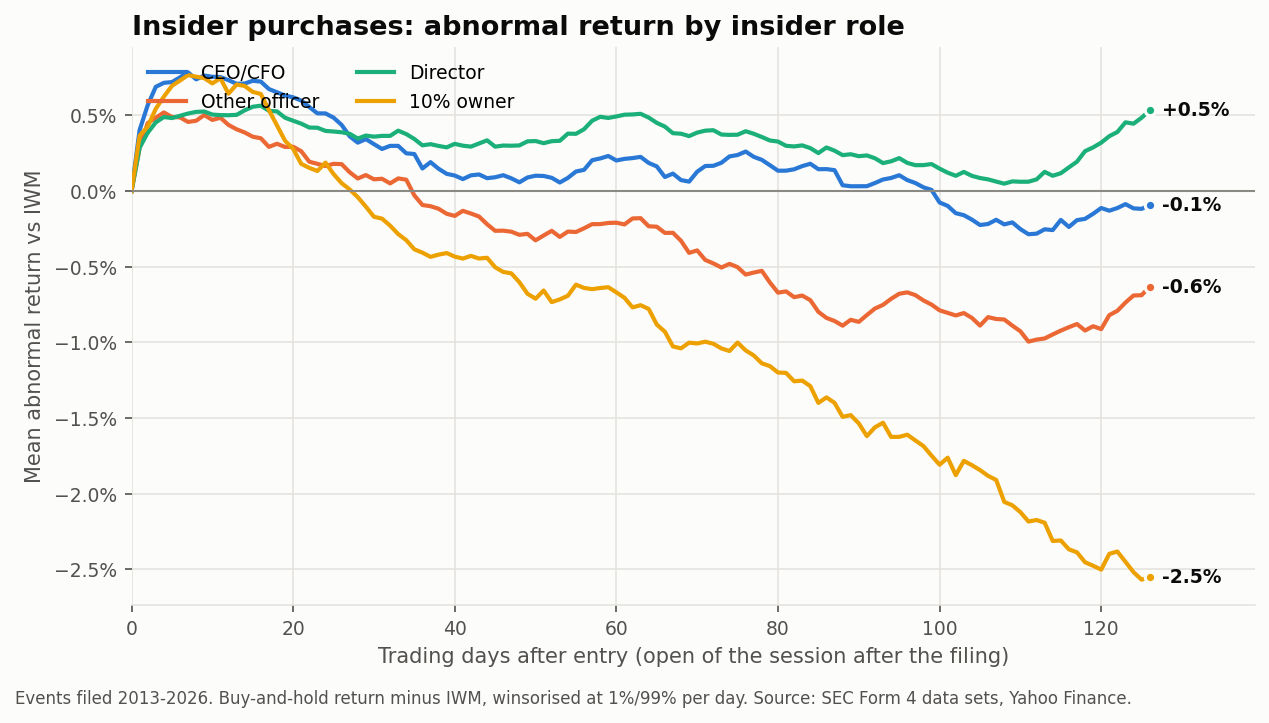

In [4]:
Image(FIG / "fig1_car_by_role.png")

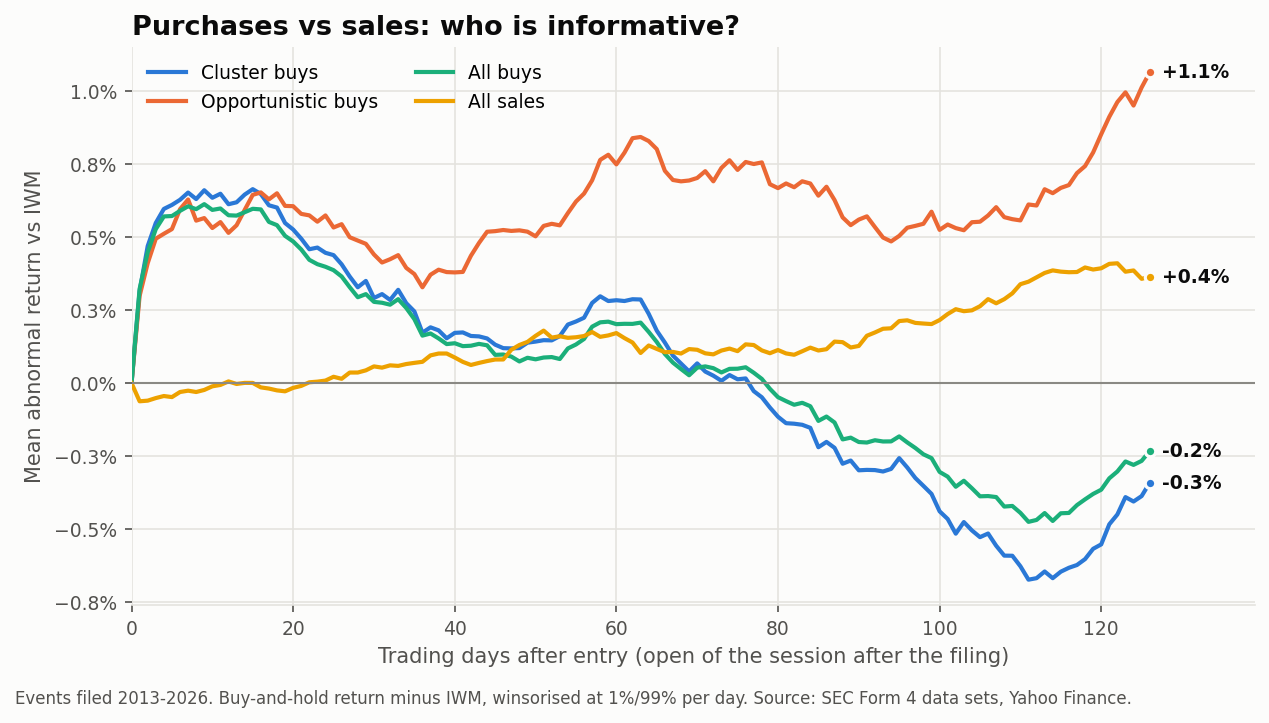

In [5]:
Image(FIG / "fig2_buys_vs_sells.png")

### Who captures the return?

Part of the move happens before an outsider can trade. It accrues between the insider's own trade and the filing, and then overnight after the filing is published.

In [6]:
pd.read_csv(RES / "return_timeline.csv").round(4)

,window,mean,t
0,Insider's trade date -> filing date close,0.0055,21.9164
1,Filing-day close -> next open (overnight),0.0073,25.7664
2,Entry open -> day 5 close,0.0058,11.9241
3,Entry open -> day 21 close,0.0047,3.0967
4,Entry open -> day 63 close,0.0024,0.8180


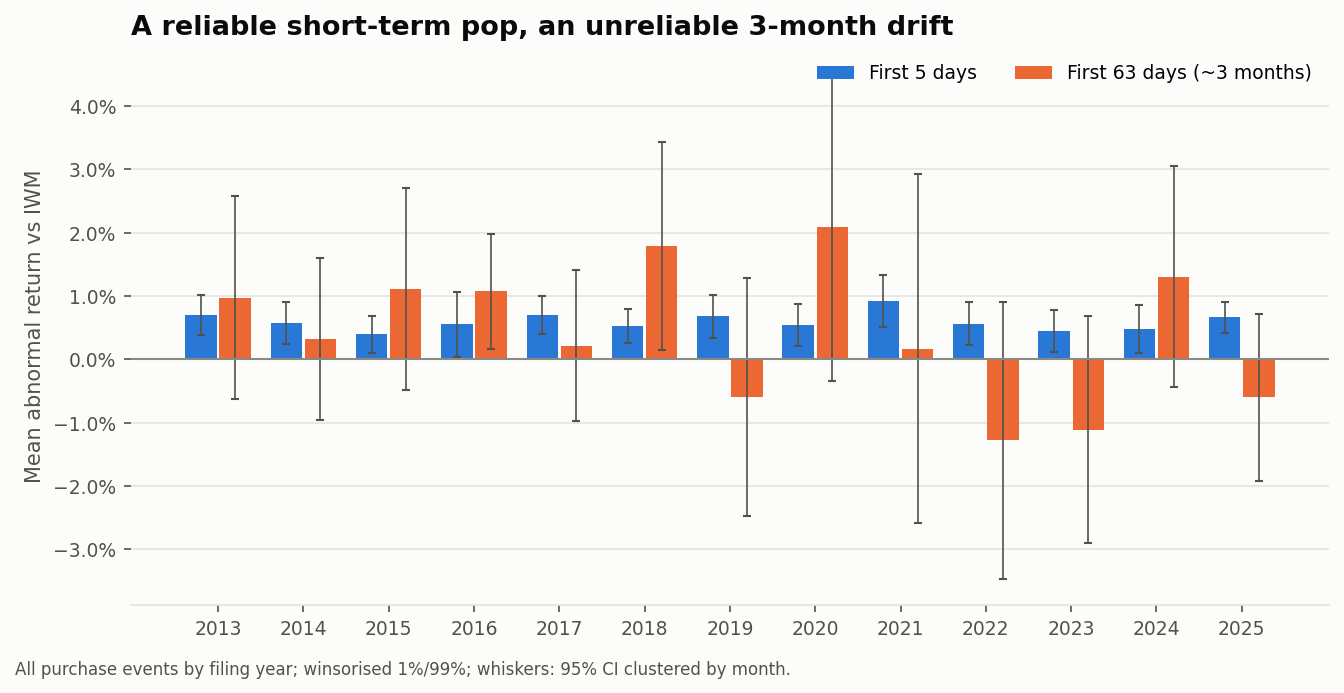

In [7]:
Image(FIG / "fig9_signal_by_year.png")

## 3. Is insider skill persistent?

Each insider's track record uses only earlier purchases whose 63-day outcome window had **already closed** before the new filing.

In [8]:
pd.read_csv(RES / "skill_persistence.csv").round(4)

,track_record_quintile,n,past_mean_bhar,future_bhar_63d,t_stat,se
0,Q1,11486,-0.1389,-0.0065,-0.9408,0.0070
1,Q2,11485,-0.0265,0.0052,1.1863,0.0044
2,Q3,11486,0.0040,0.0042,1.0509,0.0040
3,Q4,11485,0.0391,0.0112,3.1503,0.0036
4,Q5,11486,0.2352,0.0063,0.9185,0.0069
5,No realised history,30845,,-0.0021,-0.4388,0.0047


In [9]:
pd.read_csv(RES / "fama_macbeth.csv", index_col=0).round(4)

,coef_per_1sd,t
const,0.0039,1.0077
tr_shrunk,0.0021,0.9472
log_value,-0.0004,-0.2129
own_chg,-0.0007,-0.5217
cluster_insiders_30d,-0.0022,-1.0850
log_adv,0.0022,0.9285
mom_6m_skip1m,0.0031,1.0111
vol_3m,-0.0027,-0.5580


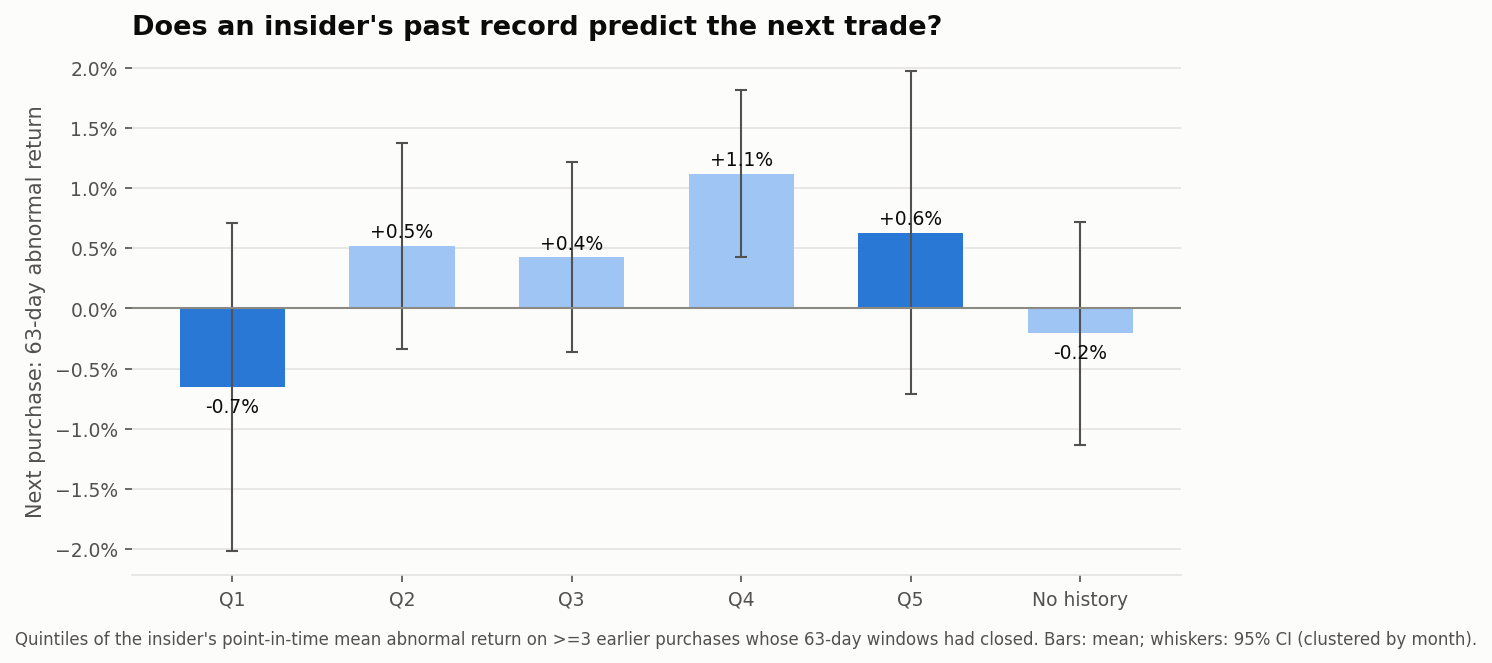

In [10]:
Image(FIG / "fig3_skill_persistence.png")

## 4. Walk-forward ML ranking

- **Retraining:** the model is retrained every quarter on events whose 63-day label had already been realised.
- **Trading threshold:** the top-20% cut-off comes from the training data's score distribution.
- **Model choice:** gradient boosting was fixed as the primary model before any out-of-sample result was seen. Logistic regression and AdaBoost are shown as comparisons.

In [11]:
mm = pd.read_csv(RES / "model_oos_metrics.csv")
mm[mm["year"] == "all"].round(3)

,model,year,n,auc,rank_ic,q5_minus_q1
11,logit,all,65115,0.516,0.053,0.026
23,adaboost,all,65115,0.517,0.045,0.018
35,gbm,all,65115,0.530,0.068,0.049


In [12]:
mm[mm["model"] == meta["best_model"]].round(3)

,model,year,n,auc,rank_ic,q5_minus_q1
24,gbm,2016,4968,0.493,-0.032,-0.015
25,gbm,2017,4648,0.500,0.001,-0.028
26,gbm,2018,6289,0.568,0.170,0.090
27,gbm,2019,6003,0.502,-0.018,-0.002
28,gbm,2020,7938,0.535,0.070,0.076
29,gbm,2021,6439,0.543,0.078,0.044
30,gbm,2022,7972,0.545,0.112,0.100
31,gbm,2023,6784,0.521,0.053,0.050
32,gbm,2024,5831,0.557,0.119,0.081
33,gbm,2025,6564,0.543,0.113,0.062


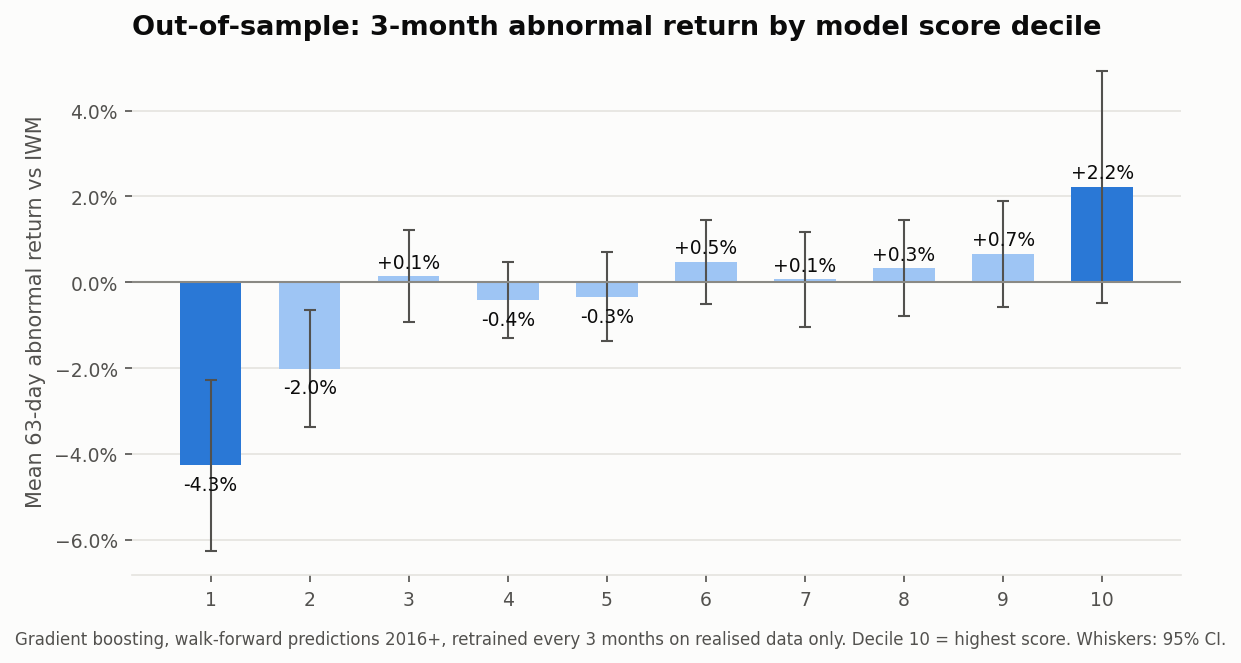

In [13]:
Image(FIG / "fig5_score_deciles.png")

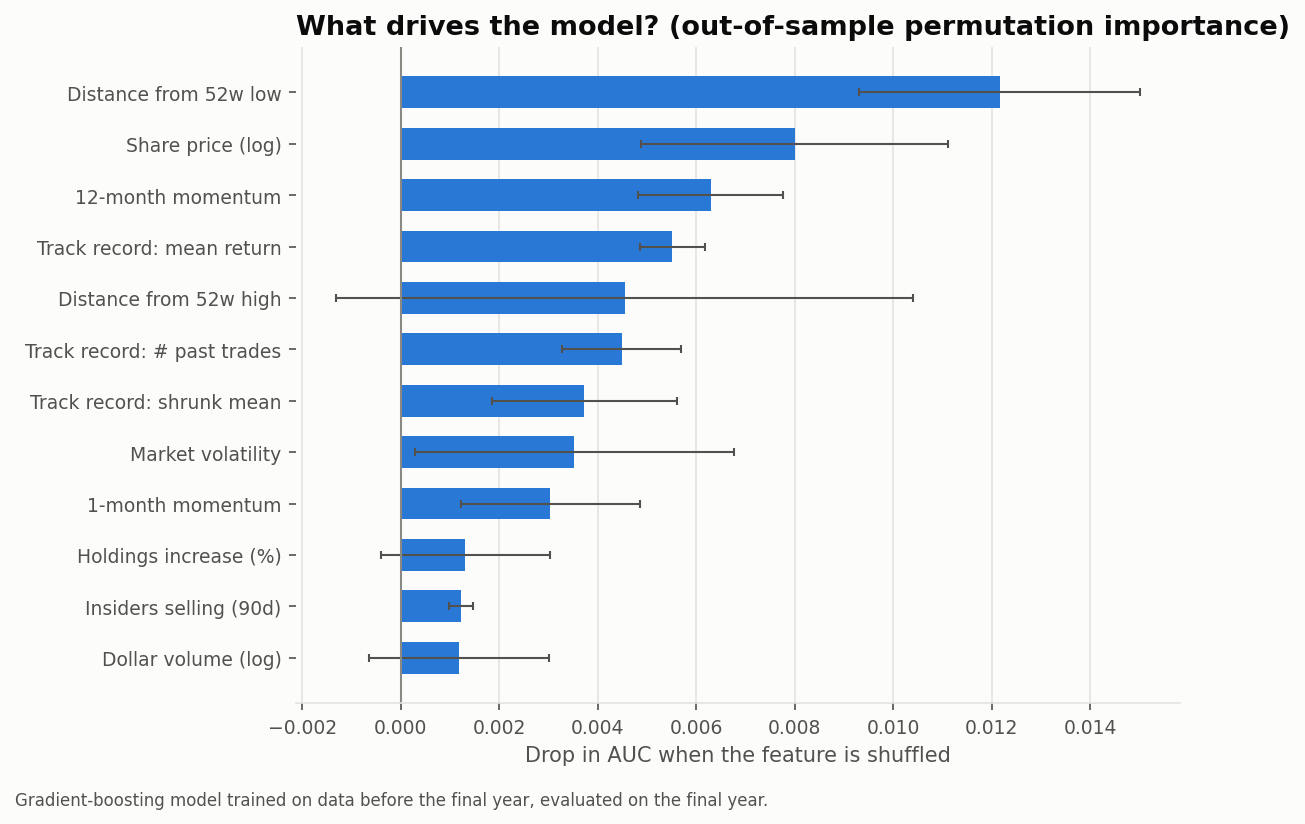

In [14]:
Image(FIG / "fig6_feature_importance.png")

## 5. Portfolio backtest

- **Entry and hold:** enter at the next open after the filing and hold 63 sessions; positions drift with their own prices.
- **Costs:** 5 to 60 bps per side depending on liquidity.
- **Universe:** price of at least $2 and at least $250k/day of dollar volume.
- **Benchmarks:** IWM, SPY and Fama-French 5 factors + momentum.

In [15]:
bt = pd.read_csv(RES / "backtest_summary.csv")
bt[["strategy", "cagr", "vol", "sharpe", "sharpe_ci_low", "sharpe_ci_high", "max_dd", "ff6_alpha_ann", "ff6_alpha_t",
    "beta_mkt", "deflated_sharpe_prob"]].round(3)

,strategy,cagr,vol,sharpe,sharpe_ci_low,sharpe_ci_high,max_dd,ff6_alpha_ann,ff6_alpha_t,beta_mkt,deflated_sharpe_prob
0,ML top 20% (gbm),0.115,0.267,0.458,-0.191,1.147,-0.566,0.012,0.287,0.945,0.697
1,All investable buys,0.097,0.233,0.419,-0.202,1.078,-0.480,-0.011,-0.585,0.927,0.653
2,CEO/CFO buys,0.075,0.247,0.327,-0.320,1.032,-0.507,-0.026,-0.853,0.927,0.539
3,Cluster buys,0.093,0.237,0.398,-0.244,1.037,-0.490,-0.012,-0.486,0.910,0.628
4,Opportunistic buys,0.112,0.226,0.483,-0.139,1.144,-0.442,0.004,0.153,0.892,0.724
5,Track-record insiders (point-in-time),0.086,0.233,0.376,-0.238,1.021,-0.511,-0.023,-0.860,0.906,0.601
6,ML bottom 20% (gbm),-0.059,0.279,-0.157,-0.755,0.445,-0.850,-0.148,-2.992,0.910,0.071
7,ML top 20% (logit),0.113,0.236,0.479,-0.166,1.170,-0.521,0.008,0.252,0.893,0.720
8,ML top 20% (adaboost),0.068,0.225,0.305,-0.275,0.967,-0.524,-0.038,-1.249,0.870,0.510
9,Long-short: ML top - bottom 20% (gbm),0.056,0.211,0.258,-0.307,0.913,-0.460,0.049,0.753,0.035,0.451


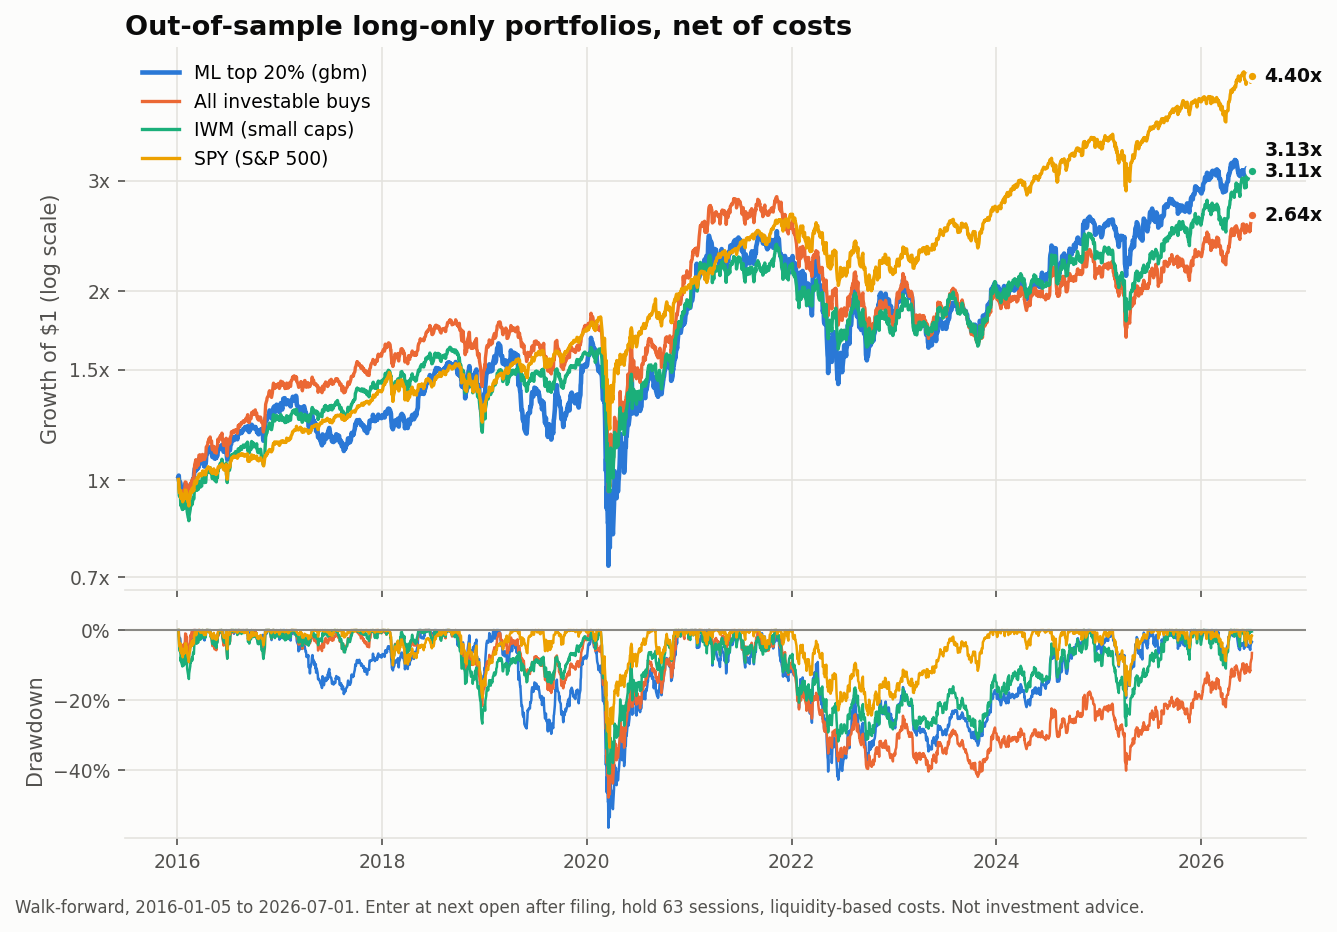

In [16]:
Image(FIG / "fig4_equity_curves.png")

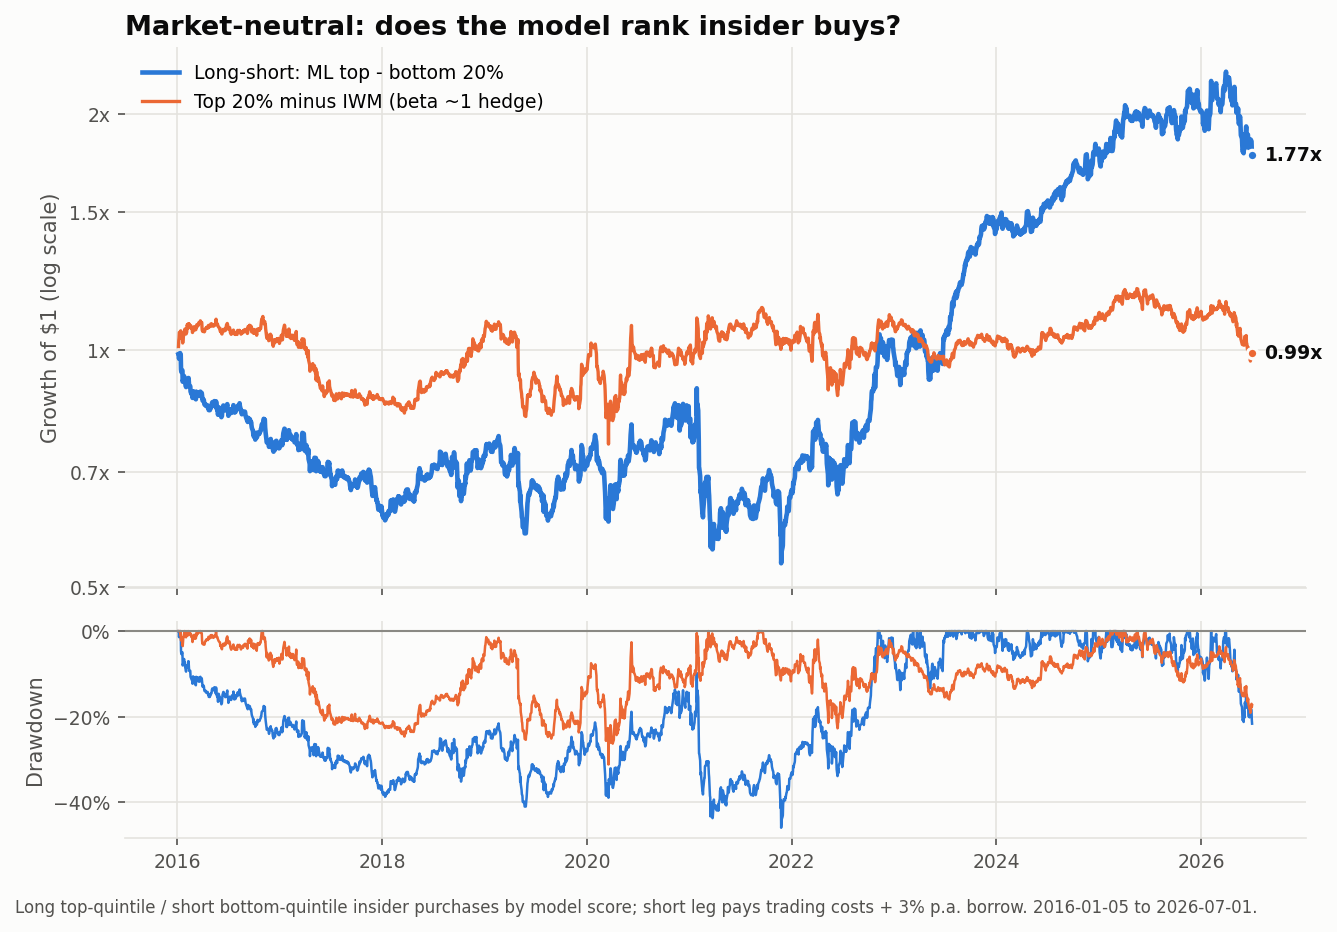

In [17]:
Image(FIG / "fig8_long_short.png")

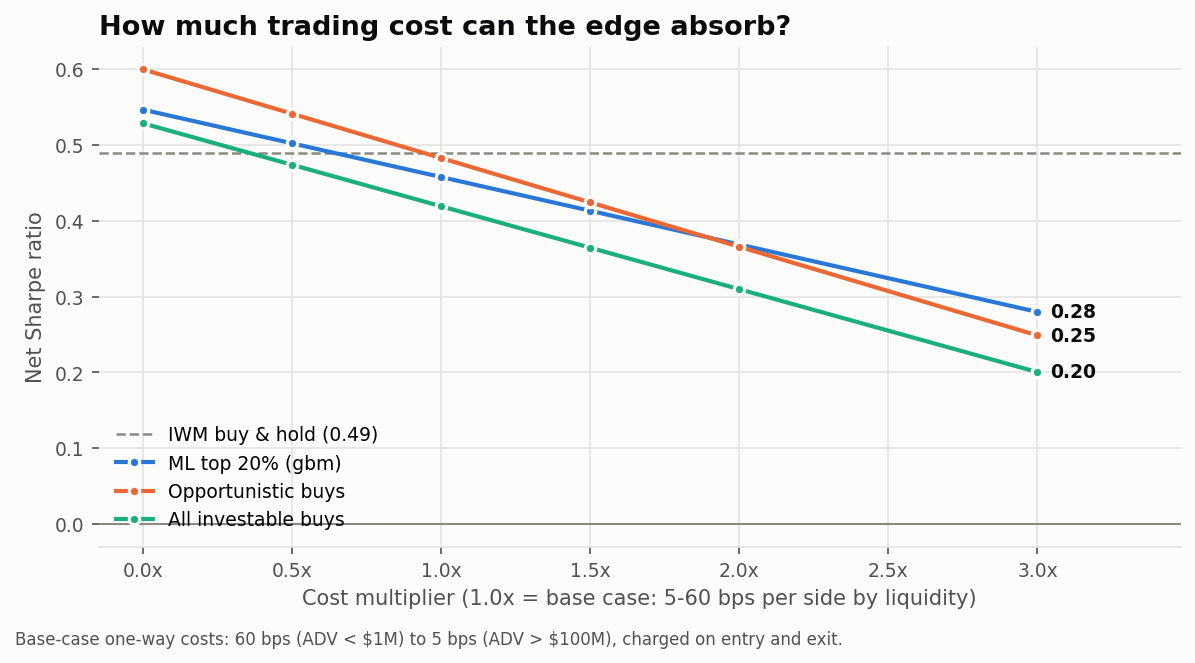

In [18]:
Image(FIG / "fig7_cost_sensitivity.png")

In [19]:
pd.read_csv(RES / "holding_period_sensitivity.csv").round(3)

,strategy,hold_days,sharpe,gross_sharpe,ff6_alpha_ann,ff6_alpha_t
0,ML top 20% (gbm),5,0.519,1.179,0.113,0.897
1,ML top 20% (gbm),10,0.388,0.800,0.022,0.252
2,ML top 20% (gbm),21,0.443,0.687,0.016,0.279
3,ML top 20% (gbm),63,0.458,0.547,0.012,0.287
4,ML top 20% (gbm),126,0.457,0.502,0.007,0.209
5,All investable buys,5,0.014,1.266,-0.095,-2.564
6,All investable buys,10,0.296,0.937,-0.035,-1.191
7,All investable buys,21,0.295,0.613,-0.038,-1.541
8,All investable buys,63,0.419,0.528,-0.011,-0.585
9,All investable buys,126,0.434,0.490,-0.011,-0.656


In [20]:
pd.read_csv(RES / "annual_returns.csv", index_col=0).round(3)

,ML top 20% (gbm),All investable buys,CEO/CFO buys,Cluster buys,Opportunistic buys,Track-record insiders (point-in-time),ML bottom 20% (gbm),ML top 20% (logit),ML top 20% (adaboost),Long-short: ML top - bottom 20% (gbm),IWM (buy & hold),SPY (buy & hold)
year,,,,,,,,,,,,
2016,0.283,0.400,0.297,0.414,0.239,0.352,0.513,0.479,0.364,-0.249,0.245,0.136
2017,-0.021,0.126,0.026,0.094,0.123,0.086,0.058,0.084,0.054,-0.157,0.146,0.217
2018,0.071,-0.050,-0.085,-0.017,-0.033,-0.048,-0.166,0.083,-0.059,0.157,-0.111,-0.046
2019,0.134,0.175,0.274,0.144,0.199,0.022,0.061,0.063,0.018,-0.027,0.254,0.312
2020,0.238,0.207,0.303,0.203,0.193,0.236,0.003,0.294,0.070,0.141,0.200,0.183
2021,0.179,0.195,0.168,0.182,0.221,0.126,0.214,0.204,0.152,-0.184,0.145,0.287
2022,-0.170,-0.283,-0.317,-0.285,-0.198,-0.275,-0.493,-0.266,-0.046,0.499,-0.205,-0.182
2023,0.102,0.096,0.096,0.086,0.072,0.099,-0.327,0.152,0.015,0.436,0.168,0.262
2024,0.228,0.073,0.013,0.097,0.125,0.094,-0.126,0.089,0.156,0.264,0.114,0.249


## Takeaways

1. Insider purchases contain real information. The short-horizon abnormal return is positive and significant in every year.
2. A large part of it is priced before an outsider can trade: between the insider's trade and the filing, and overnight after the filing.
3. Copying all insider purchases produces little or no factor alpha after costs, and short holding periods are wiped out by trading costs.
4. The ML model's clearest value is identifying **which insider purchases to avoid**. The bottom-quintile portfolio has strongly negative alpha.

See the README for limitations (survivorship in free price data, the daily filing timestamp, and the cost model).